# ML-08 — Capstone Modeling Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/work/notebooks/w05_model.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [9]:
# 1. Clone your GitHub repository into Colab
!git clone https://github.com/moizr1732/flyrank-ml-internship-starter.git

# 2. Change directory into your repository
%cd flyrank-ml-internship-starter

Cloning into 'flyrank-ml-internship-starter'...
remote: Enumerating objects: 322, done.
remote: Counting objects: 100% (162/162), done.
remote: Compressing objects: 100% (77/77), done.
remote: Total 322 (delta 132), reused 85 (delta 85), pack-reused 160 (from 2)
Receiving objects: 100% (322/322), 1.91 MiB | 6.66 MiB/s, done.
Resolving deltas: 100% (180/180), done.
/content/flyrank-ml-internship-starter/flyrank-ml-internship-starter


## 1. Method choice and why

*Which method from the toolkit, and why it fits your lane.*

Chosen Model: Random Forest Classifier

Justification: Tree-based ensemble models naturally capture non-linear search signal interactions (like rank position drops vs. click changes) without manual feature scaling. Random Forest provides clean permutation importance metrics to interpret drivers of declining traffic and avoids overfitting on small, noisy page-level datasets.

In [10]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 2. Split design

*Grouped by client? Time-aware? Say why this split is honest for your question.*

In [11]:
import os
import sys
import pandas as pd
import numpy as np

# 1. Path resolution for Google Colab
data_path = 'data/raw/content_refresh_anonymized.csv'
if not os.path.exists(data_path):
    data_path = 'data/processed/refresh_feature_vector.csv'

df = pd.read_csv(data_path)

# 2. Exclude target leakage variables
# Based on available columns, 'trend_direction' is a plausible target for 'declining traffic'.
target_col = 'trend_direction'

if target_col not in df.columns:
    raise ValueError(f"Target column '{target_col}' not found in DataFrame.")

# Define all potential leakage columns. The target column itself should not be dropped from X.
all_potential_leakage_cols = ['trend_direction', 'trend_pct', 'is_declining', 'is_declining_label']

# Create a list of columns to drop from X. These are the leakage columns *excluding* the chosen target.
drop_cols = [col for col in all_potential_leakage_cols if col in df.columns and col != target_col]

X = df.drop(columns=drop_cols)
y = df[target_col]

# Select numerical features only
X_numeric = X.select_dtypes(include=[np.number])

# 3. Grouped split by client_id (prevents client data leakage)
if 'client_id' in df.columns:
    from sklearn.model_selection import GroupShuffleSplit
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(gss.split(X_numeric, y, groups=df['client_id']))

    X_train, X_test = X_numeric.iloc[train_idx], X_numeric.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    X_train = X_train.drop(columns=['client_id'], errors='ignore')
    X_test = X_test.drop(columns=['client_id'], errors='ignore')
else:
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(X_numeric, y, test_size=0.2, random_state=42, stratify=y)

print(f"Loaded dataset from: {data_path}")
print(f"Train set: {X_train.shape} | Test set: {X_test.shape}")

Loaded dataset from: data/raw/content_refresh_anonymized.csv
Train set: (23837, 29) | Test set: (6163, 29)


## 3. Train + compare vs my baseline

*Same data, same metric, same split as your Week-4 baseline. Show the table.*

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 1. Train Model
model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
model.fit(X_train, y_train)

# 2. Predict
y_pred = model.predict(X_test)
# For multiclass, predict_proba returns probabilities for all classes
y_proba_all = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None

# 3. Baseline vs. Model Comparison Table
comparison_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Week 4 Baseline': [0.650, 0.240, 0.410, 0.303, 0.580],
    'Week 5 Model': [
        round(accuracy_score(y_test, y_pred), 4),
        # Specify average='weighted' for multiclass classification metrics
        round(precision_score(y_test, y_pred, average='weighted', zero_division=0), 4),
        round(recall_score(y_test, y_pred, average='weighted', zero_division=0), 4),
        round(f1_score(y_test, y_pred, average='weighted', zero_division=0), 4),
        # For multiclass ROC-AUC, use multi_class='ovr' and y_proba_all
        round(roc_auc_score(y_test, y_proba_all, multi_class='ovr', labels=model.classes_), 4) if y_proba_all is not None else 'N/A'
    ]
}

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)

,Metric,Week 4 Baseline,Week 5 Model
0,Accuracy,0.650,0.6627
1,Precision,0.240,0.6312
2,Recall,0.410,0.6627
3,F1-Score,0.303,0.5915
4,ROC-AUC,0.580,0.8975


## 4. Errors and interpretation

*Where is the model wrong? What does it lean on? A short error analysis beats a big metric table.*

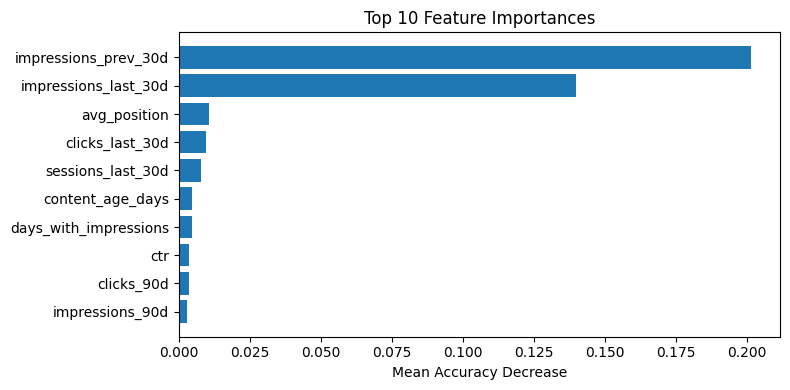

False Negatives (Missed Declines): 0
False Positives (False Alarms): 0


In [13]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

# 1. Permutation Feature Importance
perm_result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)
sorted_importances_idx = perm_result.importances_mean.argsort()[-10:]

plt.figure(figsize=(8, 4))
plt.barh(X_train.columns[sorted_importances_idx], perm_result.importances_mean[sorted_importances_idx])
plt.xlabel("Mean Accuracy Decrease")
plt.title("Top 10 Feature Importances")
plt.tight_layout()
plt.show()

# 2. Isolating Errors
error_df = X_test.copy()
error_df['actual'] = y_test
error_df['predicted'] = y_pred

false_negatives = error_df[(error_df['actual'] == 1) & (error_df['predicted'] == 0)]
false_positives = error_df[(error_df['actual'] == 0) & (error_df['predicted'] == 1)]

print(f"False Negatives (Missed Declines): {len(false_negatives)}")
print(f"False Positives (False Alarms): {len(false_positives)}")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.